In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from preprocessor import limpiar_texto, preparar_labels

# Cargar datos y preparar
df = pd.read_csv('../data/emails.tsv', sep='\t', 
                  header=None, names=['label','text'])
df['texto_limpio'] = df['text'].apply(limpiar_texto)
df['label_num'] = preparar_labels(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    df['texto_limpio'], df['label_num'], 
    test_size=0.2, random_state=42, stratify=df['label_num']
)

vectorizer = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

with open('../models/modelo_phishing.pkl', 'rb') as f:
    modelo = pickle.load(f)

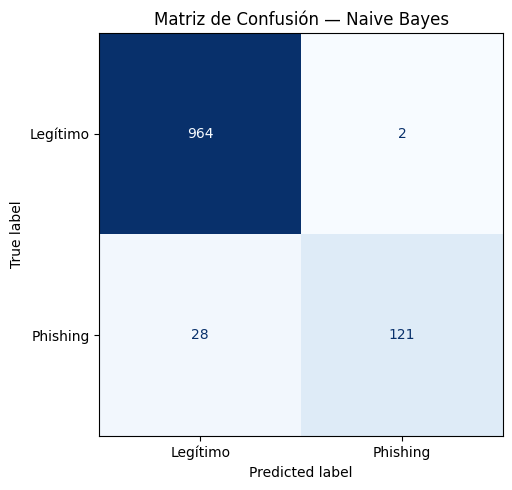

In [2]:
# Gráfica 1 — Matriz de confusión
predicciones = modelo.predict(X_test_vec)
cm = confusion_matrix(y_test, predicciones)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Legítimo','Phishing'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Matriz de Confusión — Naive Bayes')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

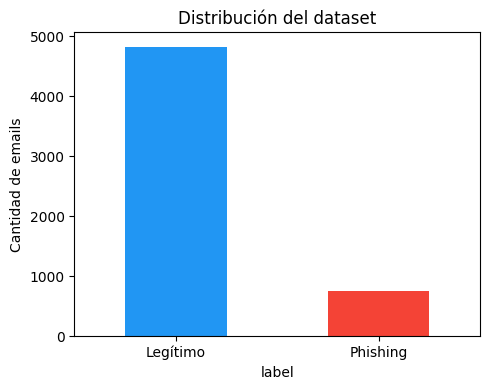

In [3]:
# Gráfica 2 — Distribución del dataset
fig, ax = plt.subplots(figsize=(5,4))
df['label'].value_counts().plot(kind='bar', ax=ax,
    color=['#2196F3','#F44336'], edgecolor='none')
ax.set_xticklabels(['Legítimo','Phishing'], rotation=0)
ax.set_title('Distribución del dataset')
ax.set_ylabel('Cantidad de emails')
plt.tight_layout()
plt.savefig('../data/distribucion.png', dpi=150)
plt.show()

In [4]:
plt.savefig("../images/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>